# Prepare UNIQUE input data for MDR1 endpoint

---

Preparing MDR1 input dataset to run UNIQUE Pipeline includes the following steps:
- Importing the preprocessed MDR1 dataset.
- Integrating predictions from Chemprop and corresponding uncertainty estimates (ensemble variance).
- Adding and scaling GNN latent fingerprints.

In [1]:
import os 
import numpy as np 
import pandas as pd
pd.set_option('display.max_columns', None)

## Load MDR1 data

In [2]:
df = pd.read_csv('data/MDR1_dataset_with_splits.csv', index_col=0)
df.head()

,Id,Structure,mol,MDCK-MDR1_LogER,Subset,split
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,<rdkit.Chem.rdchem.Mol object at 0x76625c680c10>,1.493167,Training,train
1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,<rdkit.Chem.rdchem.Mol object at 0x76625c681230>,1.040780,Training,val
2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,<rdkit.Chem.rdchem.Mol object at 0x76625c6812a0>,1.010597,Training,val
3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,<rdkit.Chem.rdchem.Mol object at 0x76625c681310>,0.860626,Training,train
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,<rdkit.Chem.rdchem.Mol object at 0x76625c6814d0>,1.301829,Training,val


In [3]:
df['which_set'] = df['Subset'].copy()
df['which_set'] = df['which_set'].replace({'Training':'TRAIN', 'Calibration':'CALIBRATION', 'Validation':'TEST'})
df['which_set'].value_counts()

which_set
TRAIN          1321
CALIBRATION     791
TEST            527
Name: count, dtype: int64

Select columns

In [4]:
df = df[['Id','Structure','MDCK-MDR1_LogER','which_set']]
df.head()

,Id,Structure,MDCK-MDR1_LogER,which_set
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.493167,TRAIN
1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,1.040780,TRAIN
2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,1.010597,TRAIN
3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,0.860626,TRAIN
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,1.301829,TRAIN


## Read model predictions

In [5]:
df_preds = pd.read_csv('MDR1_model/predictions.csv')
df_preds.head()

,Unnamed: 0,Id,Structure,mol,MDCK-MDR1_LogER,Subset,split,MDCK-MDR1_LogER_unc
0,0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,<rdkit.Chem.rdchem.Mol object at 0x76625c680c10>,1.269533,Training,train,0.003975
1,1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,<rdkit.Chem.rdchem.Mol object at 0x76625c681230>,0.732924,Training,val,0.001863
2,2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,<rdkit.Chem.rdchem.Mol object at 0x76625c6812a0>,0.963684,Training,val,0.014464
3,3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,<rdkit.Chem.rdchem.Mol object at 0x76625c681310>,1.264511,Training,train,0.001536
4,4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,<rdkit.Chem.rdchem.Mol object at 0x76625c6814d0>,1.087161,Training,val,0.002204


In [6]:
all([df.Id.iloc[x] == df_preds.Id.iloc[x] for x in range(df.shape[0])])

True

Rename columns

In [7]:
df_preds = df_preds.rename(columns={"MDCK-MDR1_LogER": "predicted MDCK-MDR1_LogER", "MDCK-MDR1_LogER_unc": "variance MDCK-MDR1_LogER"})

Select columns

In [8]:
df_preds = df_preds[['Id','predicted MDCK-MDR1_LogER','variance MDCK-MDR1_LogER']]
df_preds.head()

,Id,predicted MDCK-MDR1_LogER,variance MDCK-MDR1_LogER
0,Mol1,1.269533,0.003975
1,Mol2,0.732924,0.001863
2,Mol5,0.963684,0.014464
3,Mol6,1.264511,0.001536
4,Mol10,1.087161,0.002204


Merge predictions data

In [9]:
print(df.shape)
print(df_preds.shape)
df = df.merge(df_preds, on=['Id'])
print(df.shape)
df.head()

(2639, 4)
(2639, 3)
(2639, 6)


,Id,Structure,MDCK-MDR1_LogER,which_set,predicted MDCK-MDR1_LogER,variance MDCK-MDR1_LogER
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.493167,TRAIN,1.269533,0.003975
1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,1.040780,TRAIN,0.732924,0.001863
2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,1.010597,TRAIN,0.963684,0.014464
3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,0.860626,TRAIN,1.264511,0.001536
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,1.301829,TRAIN,1.087161,0.002204


## Read GNN latent representations

In [10]:
df_latent = pd.read_csv('MDR1_model/latent_fps_0.csv')
df_latent.head()

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299
0,0.002113,0.347930,0.117784,0.023206,0.009875,0.012594,0.0,0.015237,0.0,0.000000,0.013496,0.330417,0.091005,0.0,0.132814,0.0,0.021723,0.0,0.000000,0.000178,0.005766,0.045424,0.116383,0.122782,0.145977,0.0,0.000000,0.0,0.235287,0.0,0.047712,0.041097,0.034099,0.180480,0.000000,0.200701,0.004151,0.041048,0.004993,0.001421,0.000000,0.0,0.016329,0.0,0.022676,0.035536,0.0,0.164353,0.0,0.012871,0.000000,0.030415,0.007002,0.014238,0.0,0.217204,0.002217,0.087931,0.314555,0.051908,0.074196,0.293687,0.031333,0.053071,0.0,0.048516,0.135735,0.006498,0.086101,0.042957,0.036090,0.0,0.0,0.024147,0.0,0.068424,0.082511,0.000000,0.0,0.096849,0.0,0.008595,0.034450,0.103733,0.000000,0.328920,0.018051,0.0,0.143064,0.162693,0.023306,0.0,0.218003,0.0,0.118471,0.353303,0.081744,0.008323,0.022932,0.208052,0.005040,0.202819,0.134356,0.007744,0.000536,0.013078,0.0,0.008879,0.005437,0.175987,0.001093,0.004339,0.036643,0.047980,0.0,0.0,0.0,0.0,0.0,0.028169,0.120335,0.023804,0.007400,0.0,0.011190,0.0,0.0,0.000000,0.230906,0.000000,0.010327,0.0,0.0,0.0,0.0,0.088859,0.176293,0.001287,0.242808,0.000000,0.003410,0.176662,0.019416,0.0,0.005394,0.0,0.100485,0.051524,0.197221,0.009282,0.016247,0.000915,0.0,0.000000,0.0,0.030158,0.092010,0.217594,0.143970,0.092308,0.167320,0.000000,0.003222,0.001770,0.031554,0.028063,0.000308,0.000247,0.055649,0.000373,0.000000,0.134242,0.0,0.031047,0.0,0.061301,0.0,0.0,0.012322,0.001684,0.008533,0.188680,0.0,0.044879,0.0,0.014185,0.223993,0.000000,0.070949,0.027929,0.026950,0.119256,0.000000,0.093262,0.045408,0.0,0.000412,0.0,0.013814,0.043726,0.0,0.0,0.075493,0.0,0.004413,0.053842,0.033774,0.034160,0.157999,0.0,0.038199,0.000000,0.158610,0.058590,0.0,0.0,0.0,0.034946,0.000000,0.040694,0.012649,0.007113,0.0,0.055675,0.248610,0.243134,0.045249,0.018611,0.016774,0.199285,0.038548,0.023828,0.004609,0.028395,0.025631,0.0,0.00002,0.000000,0.001920,0.0,0.0,0.000000,0.000153,0.000374,0.018946,0.056745,0.192294,0.0,0.000014,0.0,0.000000,0.002594,0.0,0.0,0.193279,0.001139,0.342670,0.158

Add SMILES data

In [11]:
original_data = pd.read_csv('data/MDR1_dataset_with_splits.csv', index_col=0)
smiles = original_data['Structure']
smiles

0       CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...
1       CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1
2       CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...
3       CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...
4       CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...
                              ...                        
2634    Cc1ccc(Nc2nccc(N(C)c3ccc4c(C)n(C)nc4c3)n2)cc1S...
2635                              O=C(NNc1ccccc1)c1ccncc1
2636    CN(C)C(=O)C(CCN1CCC(O)(c2ccc(Cl)cc2)CC1)(c1ccc...
2637    COc1cc2c(cc1OC)CN(C(=O)C1CCCN(C(=O)c3ccc(Cl)cc...
2638              O=C(c1ccc2c(c1)CCCC2)N1CCOCC1c1ccn[nH]1
Name: Structure, Length: 2639, dtype: object

In [12]:
print(df_latent.shape)
print(smiles.shape)
df_latent = pd.concat([smiles, df_latent], axis=1)
print(df_latent.shape)
df_latent.head()

(2639, 300)
(2639,)
(2639, 301)


,Structure,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299
0,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.002113,0.347930,0.117784,0.023206,0.009875,0.012594,0.0,0.015237,0.0,0.000000,0.013496,0.330417,0.091005,0.0,0.132814,0.0,0.021723,0.0,0.000000,0.000178,0.005766,0.045424,0.116383,0.122782,0.145977,0.0,0.000000,0.0,0.235287,0.0,0.047712,0.041097,0.034099,0.180480,0.000000,0.200701,0.004151,0.041048,0.004993,0.001421,0.000000,0.0,0.016329,0.0,0.022676,0.035536,0.0,0.164353,0.0,0.012871,0.000000,0.030415,0.007002,0.014238,0.0,0.217204,0.002217,0.087931,0.314555,0.051908,0.074196,0.293687,0.031333,0.053071,0.0,0.048516,0.135735,0.006498,0.086101,0.042957,0.036090,0.0,0.0,0.024147,0.0,0.068424,0.082511,0.000000,0.0,0.096849,0.0,0.008595,0.034450,0.103733,0.000000,0.328920,0.018051,0.0,0.143064,0.162693,0.023306,0.0,0.218003,0.0,0.118471,0.353303,0.081744,0.008323,0.022932,0.208052,0.005040,0.202819,0.134356,0.007744,0.000536,0.013078,0.0,0.008879,0.005437,0.175987,0.001093,0.004339,0.036643,0.047980,0.0,0.0,0.0,0.0,0.0,0.028169,0.120335,0.023804,0.007400,0.0,0.011190,0.0,0.0,0.000000,0.230906,0.000000,0.010327,0.0,0.0,0.0,0.0,0.088859,0.176293,0.001287,0.242808,0.000000,0.003410,0.176662,0.019416,0.0,0.005394,0.0,0.100485,0.051524,0.197221,0.009282,0.016247,0.000915,0.0,0.000000,0.0,0.030158,0.092010,0.217594,0.143970,0.092308,0.167320,0.000000,0.003222,0.001770,0.031554,0.028063,0.000308,0.000247,0.055649,0.000373,0.000000,0.134242,0.0,0.031047,0.0,0.061301,0.0,0.0,0.012322,0.001684,0.008533,0.188680,0.0,0.044879,0.0,0.014185,0.223993,0.000000,0.070949,0.027929,0.026950,0.119256,0.000000,0.093262,0.045408,0.0,0.000412,0.0,0.013814,0.043726,0.0,0.0,0.075493,0.0,0.004413,0.053842,0.033774,0.034160,0.157999,0.0,0.038199,0.000000,0.158610,0.058590,0.0,0.0,0.0,0.034946,0.000000,0.040694,0.012649,0.007113,0.0,0.055675,0.248610,0.243134,0.045249,0.018611,0.016774,0.199285,0.038548,0.023828,0.004609,0.028395,0.025631,0.0,0.00002,0.000000,0.001920,0.0,0.0,0.000000,0.000153,0.000374,0.018946,0.056745,0.192294,0.0,0.000014,0.

Inspect feature distributions and outlier identification

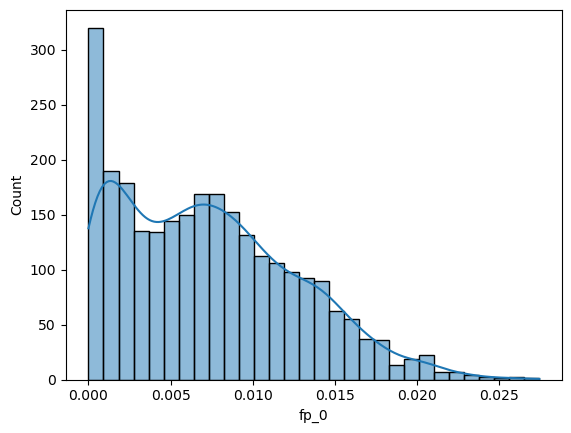

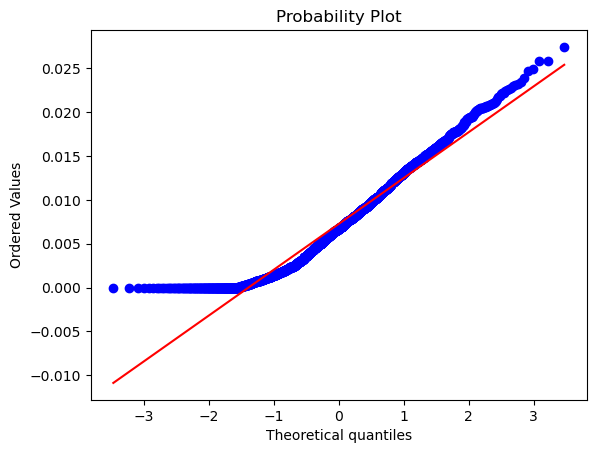

In [13]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# inspect the first latent feature
feature = df_latent['fp_0']
# histogram
sns.histplot(feature, kde=True, bins=30)
plt.show()
# Q-Q plot
stats.probplot(feature, dist="norm", plot=plt)
plt.show()

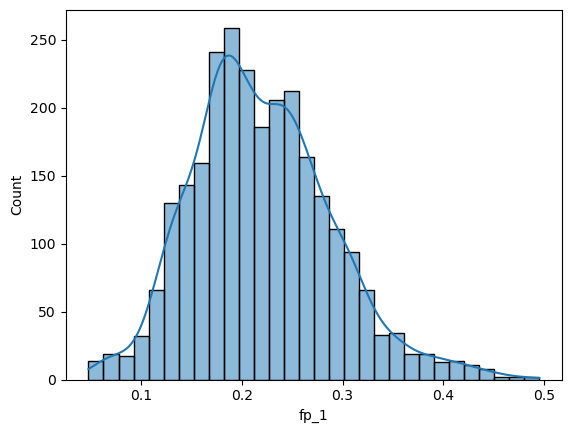

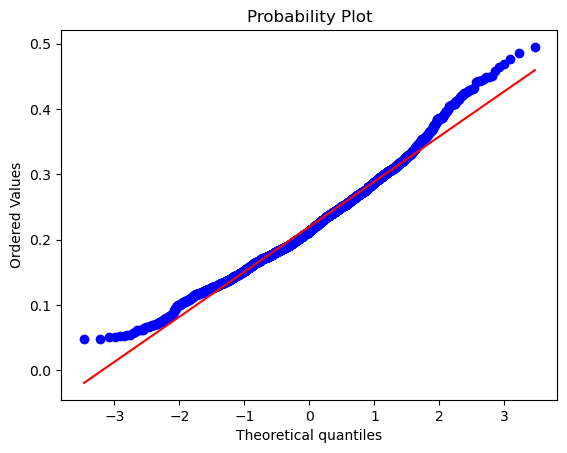

In [14]:
# inspect the second latent feature
feature = df_latent['fp_1']
# histogram
sns.histplot(feature, kde=True, bins=30)
plt.show()
# Q-Q plot
stats.probplot(feature, dist="norm", plot=plt)
plt.show()

In [15]:
print(df_latent['fp_0'].skew(axis=0, skipna=True))
print(df_latent['fp_1'].skew())

0.5727020387273809
0.5140748968091914


In [16]:
def detect_outliers(df, feature):
    zscores = (df[feature] - df[feature].mean())/df[feature].std(ddof=0)

    lower_outliers = df[zscores < -3]
    upper_outliers = df[zscores > 3]

    lower_percent = len(lower_outliers) / len(df) * 100
    upper_percent = len(upper_outliers) / len(df) * 100

    return lower_percent, upper_percent

In [17]:
lower_percent, upper_percent = detect_outliers(df_latent, 'fp_0')
print(lower_percent, upper_percent)
lower_percent, upper_percent = detect_outliers(df_latent, 'fp_1')
print(lower_percent, upper_percent)

0.0 0.2652519893899204
0.0 0.6820765441455097


Add latent fingerprint descriptors in a single column and scale them

In [18]:
df_latent['latent_fp'] = [np.array(df_latent.iloc[x, np.where(['fp_' in col for col in df_latent.columns])[0]]) for x in range(df_latent.shape[0])]
df_latent.head()

,Structure,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299,latent_fp
0,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.002113,0.347930,0.117784,0.023206,0.009875,0.012594,0.0,0.015237,0.0,0.000000,0.013496,0.330417,0.091005,0.0,0.132814,0.0,0.021723,0.0,0.000000,0.000178,0.005766,0.045424,0.116383,0.122782,0.145977,0.0,0.000000,0.0,0.235287,0.0,0.047712,0.041097,0.034099,0.180480,0.000000,0.200701,0.004151,0.041048,0.004993,0.001421,0.000000,0.0,0.016329,0.0,0.022676,0.035536,0.0,0.164353,0.0,0.012871,0.000000,0.030415,0.007002,0.014238,0.0,0.217204,0.002217,0.087931,0.314555,0.051908,0.074196,0.293687,0.031333,0.053071,0.0,0.048516,0.135735,0.006498,0.086101,0.042957,0.036090,0.0,0.0,0.024147,0.0,0.068424,0.082511,0.000000,0.0,0.096849,0.0,0.008595,0.034450,0.103733,0.000000,0.328920,0.018051,0.0,0.143064,0.162693,0.023306,0.0,0.218003,0.0,0.118471,0.353303,0.081744,0.008323,0.022932,0.208052,0.005040,0.202819,0.134356,0.007744,0.000536,0.013078,0.0,0.008879,0.005437,0.175987,0.001093,0.004339,0.036643,0.047980,0.0,0.0,0.0,0.0,0.0,0.028169,0.120335,0.023804,0.007400,0.0,0.011190,0.0,0.0,0.000000,0.230906,0.000000,0.010327,0.0,0.0,0.0,0.0,0.088859,0.176293,0.001287,0.242808,0.000000,0.003410,0.176662,0.019416,0.0,0.005394,0.0,0.100485,0.051524,0.197221,0.009282,0.016247,0.000915,0.0,0.000000,0.0,0.030158,0.092010,0.217594,0.143970,0.092308,0.167320,0.000000,0.003222,0.001770,0.031554,0.028063,0.000308,0.000247,0.055649,0.000373,0.000000,0.134242,0.0,0.031047,0.0,0.061301,0.0,0.0,0.012322,0.001684,0.008533,0.188680,0.0,0.044879,0.0,0.014185,0.223993,0.000000,0.070949,0.027929,0.026950,0.119256,0.000000,0.093262,0.045408,0.0,0.000412,0.0,0.013814,0.043726,0.0,0.0,0.075493,0.0,0.004413,0.053842,0.033774,0.034160,0.157999,0.0,0.038199,0.000000,0.158610,0.058590,0.0,0.0,0.0,0.034946,0.000000,0.040694,0.012649,0.007113,0.0,0.055675,0.248610,0.243134,0.045249,0.018611,0.016774,0.199285,0.038548,0.023828,0.004609,0.028395,0.025631,0.0,0.00002,0.000000,0.001920,0.0,0.0,0.000000,0.000153,0.000374,0.018946,0.056745,0.192294,0.0,0

Merge latent representations

In [19]:
set(df.Structure) == set(df_latent.Structure)

True

In [20]:
print(df.shape)
print(df_latent.shape)
df = df.merge(df_latent[['Structure','latent_fp']], on=['Structure'])
print(df.shape)
df.head()

(2639, 6)
(2639, 302)
(2639, 7)


,Id,Structure,MDCK-MDR1_LogER,which_set,predicted MDCK-MDR1_LogER,variance MDCK-MDR1_LogER,latent_fp
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.493167,TRAIN,1.269533,0.003975,"[0.0021134792, 0.3479303, 0.11778368, 0.023206..."
1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,1.040780,TRAIN,0.732924,0.001863,"[0.007371584, 0.2881622, 0.097246245, 0.015862..."
2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,1.010597,TRAIN,0.963684,0.014464,"[0.012290375, 0.29359218, 0.093072526, 0.02064..."
3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,0.860626,TRAIN,1.264511,0.001536,"[0.006371586, 0.256976, 0.07458666, 0.02972751..."
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,1.301829,TRAIN,1.087161,0.002204,"[0.0049409093, 0.41000122, 0.14240618, 0.01770..."


Given that most of latent fingerprint features show a positively skewed distribution (which does not follow a Gaussian distribution) and have a significant percentage of outliers (more than 0.3% as determined from the Z-score detection method), we employed a Robust Scaler to perform feature transformation, rather than using a Standard Scaler.

In [21]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaler.fit(np.array([np.array(x) for x in df[df.which_set == 'TRAIN'].latent_fp]))
df['latent_fp_scaled'] = [list(i) for i in scaler.transform(np.array([np.array(x) for x in df.latent_fp]))]
df = df.drop(columns='latent_fp')
df.head()

,Id,Structure,MDCK-MDR1_LogER,which_set,predicted MDCK-MDR1_LogER,variance MDCK-MDR1_LogER,latent_fp_scaled
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.493167,TRAIN,1.269533,0.003975,"[-0.5594313868230498, 1.3916011606526633, 1.25..."
1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,1.040780,TRAIN,0.732924,0.001863,"[0.06418732762765597, 0.7519633075711362, 0.57..."
2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,1.010597,TRAIN,0.963684,0.014464,"[0.6475629423684846, 0.8100749214500386, 0.440..."
3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,0.860626,TRAIN,1.264511,0.001536,"[-0.05441385871866343, 0.418208779423661, -0.1..."
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,1.301829,TRAIN,1.087161,0.002204,"[-0.2240941519772874, 2.0558837797688003, 2.07..."


## Save final datasets

Save the generated UNIQUE input dataset for each endpoint into a separate CSV file.

In [22]:
for endpoint in ['MDCK-MDR1_LogER']:

    print(f'\n{endpoint}')
    df_endpoint = df[['Id', 'Structure', f'{endpoint}', f'predicted {endpoint}', f'variance {endpoint}', 'which_set', 'latent_fp_scaled']]
    df_endpoint.columns = ['Id', 'Structure', 'labels', 'predictions', 'variance', 'which_set', 'latent_fp_scaled']

    print(df_endpoint.shape)
    df_endpoint = df_endpoint.dropna()
    print(df_endpoint.shape)

    print(df_endpoint.which_set.value_counts())
    print(df_endpoint.which_set.value_counts()/df_endpoint.which_set.value_counts().sum() * 100)

    if not os.path.exists('unique_input_data'):
        os.makedirs('unique_input_data')

    df_endpoint.to_csv(f'unique_input_data/{endpoint}_unique_input_data.csv')


MDCK-MDR1_LogER
(2639, 7)
(2639, 7)
which_set
TRAIN          1321
CALIBRATION     791
TEST            527
Name: count, dtype: int64
which_set
TRAIN          50.056840
CALIBRATION    29.973475
TEST           19.969685
Name: count, dtype: float64
